# Milestone 1: Predictive Analytics for Customer Churn

**Milestone Title:** AI for Tabular Data — Predictive Analytics for Customer Churn  
**Dataset:** Telco Customer Churn Dataset  
**Student:** Jinghuan Zou

This notebook builds a predictive model to identify customers who are likely to churn from a subscription-based telecommunications service. It follows the required workflow: data sourcing, data cleaning, exploratory data analysis, feature engineering, model selection, evaluation, and conclusion.


## 1. Import libraries

This section imports the Python libraries required for data analysis, visualisation, preprocessing, machine learning model training, and model evaluation.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)


## 2. Load dataset

The dataset used in this project is the Telco Customer Churn dataset. It contains customer demographic information, service usage, account information, and churn labels.

In Google Colab, upload `Telco_customer_churn.xlsx` when prompted.


In [17]:
# Option A: Run this in Google Colab and upload the Excel file when prompted.
# The expected file is: Telco_customer_churn.xlsx

try:
    from google.colab import files
    uploaded = files.upload()
    uploaded_file = list(uploaded.keys())[0]
    print("Uploaded file:", uploaded_file)
    df = pd.read_excel(uploaded_file, sheet_name='Telco_Churn')
except Exception:
    # Option B: Run locally if the file is already in the same folder as this notebook.
    df = pd.read_excel('Telco_customer_churn.xlsx', sheet_name='Telco_Churn')

df.head()


Saving Telco_customer_churn(1) (1).xlsx to Telco_customer_churn(1) (1) (1).xlsx
Uploaded file: Telco_customer_churn(1) (1) (1).xlsx


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [18]:
# Check the size and basic structure of the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.info()


Dataset shape: (7043, 33)

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7

## 3. Data Cleaning

This section checks missing values, standardises column names, converts numerical columns where needed, and removes columns that should not be used for prediction.

Some columns, such as `Churn Score`, `Churn Reason`, and `Churn Label`, are not used as input features because they could cause data leakage or duplicate the target variable.


In [19]:
# Standardise column names to make coding easier
df.columns = df.columns.str.strip().str.replace(" ", "_")

# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]


,0
Churn_Reason,5174


In [20]:
# Convert Total_Charges to numeric
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# Fill possible missing Total_Charges values with the median
df['Total_Charges'] = df['Total_Charges'].fillna(df['Total_Charges'].median())

# Check duplicated records
print("Duplicated rows:", df.duplicated().sum())

# Confirm missing values after cleaning
df.isnull().sum().sort_values(ascending=False).head(10)


Duplicated rows: 0


,0
Churn_Reason,5174
CustomerID,0
Count,0
State,0
Country,0
Zip_Code,0
Lat_Long,0
Latitude,0
City,0
Gender,0


## 4. Exploratory Data Analysis (EDA)

This section explores churn distribution and important numerical relationships. EDA helps understand the dataset before model training.


Churn_Label
No     5174
Yes    1869
Name: count, dtype: int64


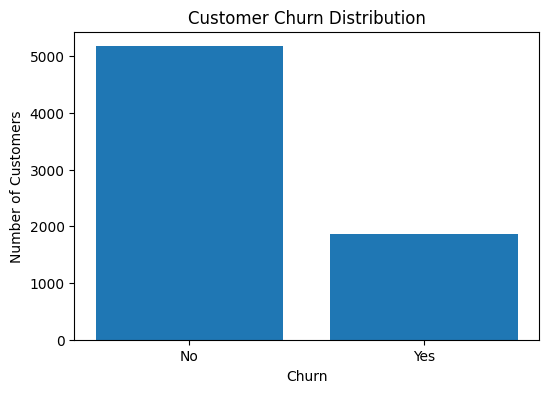

In [21]:
# Churn distribution
churn_counts = df['Churn_Label'].value_counts()
print(churn_counts)

plt.figure(figsize=(6, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


In [22]:
# Churn rate
churn_rate = df['Churn_Value'].mean()
print(f"Churn rate: {churn_rate:.2%}")


Churn rate: 26.54%


<Figure size 600x400 with 0 Axes>

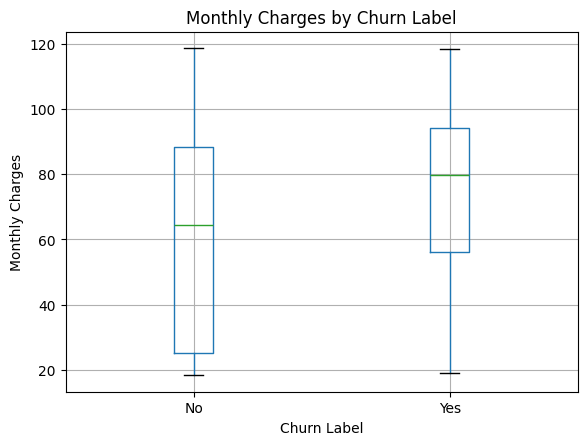

In [23]:
# Compare monthly charges by churn label
plt.figure(figsize=(6, 4))
df.boxplot(column='Monthly_Charges', by='Churn_Label')
plt.title("Monthly Charges by Churn Label")
plt.suptitle("")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charges")
plt.show()


<Figure size 600x400 with 0 Axes>

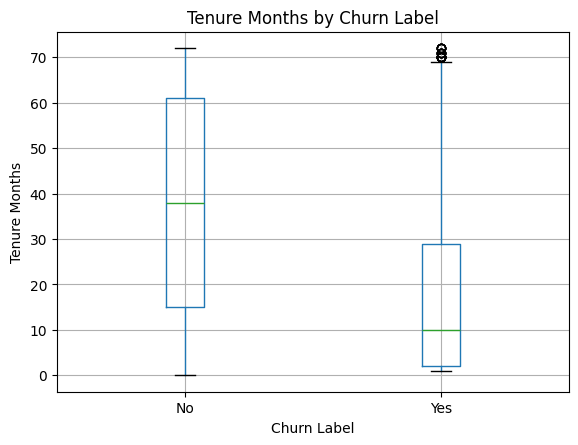

In [24]:
# Compare tenure by churn label
plt.figure(figsize=(6, 4))
df.boxplot(column='Tenure_Months', by='Churn_Label')
plt.title("Tenure Months by Churn Label")
plt.suptitle("")
plt.xlabel("Churn Label")
plt.ylabel("Tenure Months")
plt.show()


## 5. Feature Engineering

New features are created to better represent customer behaviour:

- `tenure_group`: groups customers by how long they have stayed with the company.
- `total_services`: counts how many major services the customer uses.
- `avg_charge_per_month`: estimates average charge intensity over tenure.


In [25]:
# Create tenure group
df['tenure_group'] = pd.cut(
    df['Tenure_Months'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months']
)

# Create total services feature
service_cols = [
    'Phone_Service', 'Multiple_Lines', 'Online_Security', 'Online_Backup',
    'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies'
]

df['total_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# Create average charge per month
df['avg_charge_per_month'] = df['Total_Charges'] / df['Tenure_Months'].replace(0, 1)

df[['Tenure_Months', 'tenure_group', 'total_services', 'avg_charge_per_month']].head()


,Tenure_Months,tenure_group,total_services,avg_charge_per_month
0,2,0-12 months,3,54.075000
1,2,0-12 months,1,75.825000
2,8,0-12 months,5,102.562500
3,28,25-48 months,6,108.787500
4,49,49-72 months,6,102.781633


## 6. Train-test split and preprocessing

The dataset is split into training and testing sets. Numerical columns are standardised, and categorical columns are converted using one-hot encoding.


In [26]:
# Target variable
target = 'Churn_Value'

# Remove columns that are identifiers, target duplicates, or leakage-related information
drop_cols = [
    'CustomerID',
    'Churn_Label',
    'Churn_Value',
    'Churn_Score',
    'CLTV',
    'Churn_Reason',
    'Lat_Long',
    'Latitude',
    'Longitude',
    'Zip_Code',
    'Count',
    'Country',
    'State'
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)


Feature data shape: (7043, 23)
Target data shape: (7043,)


In [27]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Numeric features: ['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 'total_services', 'avg_charge_per_month']
Categorical features: ['City', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'tenure_group']
Training set: (5634, 23)
Testing set: (1409, 23)


## 7. Model Training

Three classification models are trained and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The first two models meet the brief requirements, while Random Forest is added as an extra model to improve comparison.


In [28]:
# Define models
models = {
    "Logistic Regression": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),

    "Decision Tree": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            class_weight='balanced',
            random_state=42
        ))
    ])
}

# Train models
for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name} trained successfully.")


Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


## 8. Evaluation

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Recall and F1-score are especially important in churn prediction because the business wants to identify as many at-risk customers as possible.


In [29]:
results = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    print("=" * 60)
    print(model_name)
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results)
results_df


Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409

Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80   

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.748758,0.518248,0.759358,0.616052,0.838689
1,Decision Tree,0.739532,0.505963,0.794118,0.618106,0.841538
2,Random Forest,0.745919,0.513986,0.786096,0.621564,0.845112


Best model based on F1-score: Random Forest


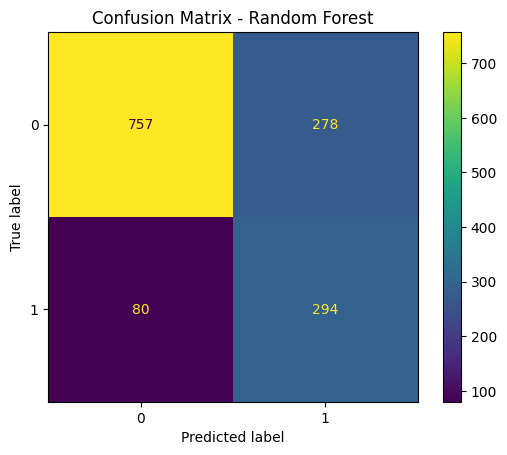

In [30]:
# Select the best model based on F1-score
best_model_name = results_df.sort_values(by='F1-score', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print("Best model based on F1-score:", best_model_name)

# Confusion matrix for the best model
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


## 9. Conclusion

This project developed a predictive analytics model to identify customers who are likely to churn from a subscription-based telecommunications service. The Telco Customer Churn dataset was selected because it includes customer demographics, service usage, account information, and historical churn labels.

The data cleaning stage included checking missing values, converting `Total Charges` into a numerical format, and removing columns that could cause data leakage. Feature engineering was also applied by creating `tenure_group`, `total_services`, and `avg_charge_per_month`.

Three machine learning models were tested: Logistic Regression, Decision Tree, and Random Forest. The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. These metrics were selected because churn prediction is not only about overall accuracy, but also about correctly identifying customers who are likely to leave.

Based on the evaluation results, the best-performing model was selected using F1-score. In a real business environment, this model could help the company identify high-risk customers earlier and design retention strategies, such as personalised offers, improved customer support, or loyalty discounts.

Future improvements could include hyperparameter tuning, cross-validation, more advanced algorithms, and additional customer behaviour data.


## References

- Kaggle. Telco Customer Churn Dataset.
- IBM Sample Data. Telco customer churn.
- Scikit-learn documentation for classification models and evaluation metrics.
